# Flash Point Modeling using DeepONets

This notebook evaluates the use of Deep Operator Networks (DeepONets) for flash point (FP) prediction and compares their performance with a standard feedforward neural network (FNN) baseline. To keep the comparison as fair as possible, both models are trained on the same experimental dataset using similar architectural settings, while still respecting the structural differences between a conventional FNN and a DeepONet.

The notebook is organized into the following stages:

- **Dependencies:** import the required libraries and define the execution setup.
- **Model Architectures:** implement the FNN and DeepONet models used in the study.
- **Data Loading:** read the experimental dataset and filter the subset used for modeling.
- **Models Training:** prepare the input features, apply 5-fold cross-validation, train both models, and track fold-level performance.
- **Models Benchmarking:** aggregate the results across folds to compare the predictive performance of both approaches.

## Dependencies

In [1]:
# Imports
import copy
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from torchmetrics import (
    MeanAbsoluteError,
    MeanSquaredError,
    MeanAbsolutePercentageError,
    R2Score,
)

# Initial setup
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 5000
DATA_PATH = Path("../data/public")

## Model Architectures

In [2]:
class FNN(nn.Module):
    """
    Standard feedforward neural network
    """

    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        hidden_width: int = 14,
        n_layers: int = 3,
        activation: type[nn.Module] = nn.ReLU,
    ) -> None:
        super().__init__()
        layers = []
        current_dim = input_dim
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(current_dim, hidden_width))
            layers.append(activation())
            current_dim = hidden_width
        layers.append(nn.Linear(current_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class DeepONet(nn.Module):
    """
    Standard DeepONet
    """

    def __init__(
        self,
        branch_dim: int,
        trunk_dim: int,
        output_dim: int = 1,
        hidden_width: int = 14,
        n_layers: int = 3,
    ) -> None:
        super().__init__()
        self.branch = FNN(branch_dim, output_dim, hidden_width, n_layers)
        self.trunk = FNN(trunk_dim, output_dim, hidden_width, n_layers)
        self.bias = nn.Parameter(torch.zeros(output_dim))

    def forward(
        self, branch_input: torch.Tensor, trunk_input: torch.Tensor
    ) -> torch.Tensor:
        B = self.branch(branch_input)
        T = self.trunk(trunk_input)

        output = torch.sum(B * T, dim=-1, keepdim=True) + self.bias

        return output

## Data Loading

In [3]:
# Reading the data into a DataFrame
data = pd.read_csv(DATA_PATH / "raw" / "fp_experimental_data.csv")

display(data)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method,FP
0,ethyl laurate,NaN,1.000,0.000,228.37,-1.450000,0,402.30
1,ethanol,octane,0.005,0.995,113.86,7.575678,1,286.15
2,ethanol,octane,0.010,0.990,113.49,7.593094,1,283.45
3,ethanol,octane,0.020,0.980,112.75,7.627042,1,281.95
4,ethanol,octane,0.030,0.970,112.00,7.659875,1,280.75
...,...,...,...,...,...,...,...,...
361,octane,NaN,1.000,0.000,114.23,7.557953,1,287.65
362,ethanol,NaN,1.000,0.000,40.07,9.078902,1,286.15
363,methyl butyrate,NaN,1.000,0.000,102.13,4.172583,1,284.55
364,propyl acetate,NaN,1.000,0.000,102.13,3.902982,1,284.55


In [4]:
# Select Method 0 (ASTM D6450) rows and keep relevant columns
filtered_data = data.loc[
    data["Method"] == 0, ["x_1", "MM", "lnPvap", "FP"]
].reset_index(drop=True)

display(filtered_data)

,x_1,MM,lnPvap,FP
0,1.0,228.37,-1.45,402.3
1,0.1,183.49,2.44,370.6
2,0.1,208.73,1.87,384.6
3,0.1,233.98,1.79,393.5
4,0.1,259.23,1.78,396.9
...,...,...,...,...
300,1.0,308.50,-7.58,453.1
301,1.0,200.32,0.82,379.5
302,1.0,40.07,9.08,288.5
303,1.0,170.33,2.89,354.4


## Models Training

In [5]:
def compute_metrics(
    predictions: torch.Tensor, targets: torch.Tensor
) -> dict[str, float]:
    """Compute regression metrics using the torchmetrics classes imported above."""
    metric_objects = {
        "mae (K)": MeanAbsoluteError().to(DEVICE),
        "rmse (K)": MeanSquaredError(squared=False).to(DEVICE),
        "mape": MeanAbsolutePercentageError().to(DEVICE),
        "r2": R2Score().to(DEVICE),
    }

    return {
        name: metric(predictions, targets).detach().cpu().item()
        for name, metric in metric_objects.items()
    }


def plot_fold_results(
    model_name: str,
    fold_idx: int,
    train_losses: list[float],
    val_losses: list[float],
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> None:
    """Plot loss evolution and experimental vs predicted FP values for a fold."""
    y_true = targets.detach().cpu().numpy().ravel()
    y_pred = predictions.detach().cpu().numpy().ravel()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_losses, label="Train loss")
    axes[0].plot(val_losses, label="Validation loss")
    axes[0].set_title(f"{model_name} - Fold {fold_idx} loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE loss")
    axes[0].legend()

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    axes[1].scatter(y_true, y_pred, alpha=0.8)
    axes[1].plot([min_value, max_value], [min_value, max_value], "k--")
    axes[1].set_title(f"{model_name} - Fold {fold_idx}")
    axes[1].set_xlabel("Experimental FP")
    axes[1].set_ylabel("Predicted FP")

    plt.tight_layout()
    plt.show()


def train_fnn_fold(
    model: FNN,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    x_val: torch.Tensor,
    y_val: torch.Tensor,
) -> tuple[list[float], list[float], torch.Tensor]:
    """Train the FNN for one fold and return loss histories and predictions."""
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    train_losses = []
    val_losses = []

    for _ in range(EPOCHS):
        model.train()
        train_predictions = model(x_train)
        train_loss = loss_fn(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val)
            val_loss = loss_fn(val_predictions, y_val)

        train_losses.append(train_loss.detach().cpu().item())
        val_losses.append(val_loss.detach().cpu().item())

    return train_losses, val_losses, val_predictions


def train_deeponet_fold(
    model: DeepONet,
    branch_train: torch.Tensor,
    trunk_train: torch.Tensor,
    y_train: torch.Tensor,
    branch_val: torch.Tensor,
    trunk_val: torch.Tensor,
    y_val: torch.Tensor,
) -> tuple[list[float], list[float], torch.Tensor]:
    """Train the DeepONet for one fold and return loss histories and predictions."""
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    train_losses = []
    val_losses = []

    for _ in range(EPOCHS):
        model.train()
        train_predictions = model(branch_train, trunk_train)
        train_loss = loss_fn(train_predictions, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(branch_val, trunk_val)
            val_loss = loss_fn(val_predictions, y_val)

        train_losses.append(train_loss.detach().cpu().item())
        val_losses.append(val_loss.detach().cpu().item())

    return train_losses, val_losses, val_predictions

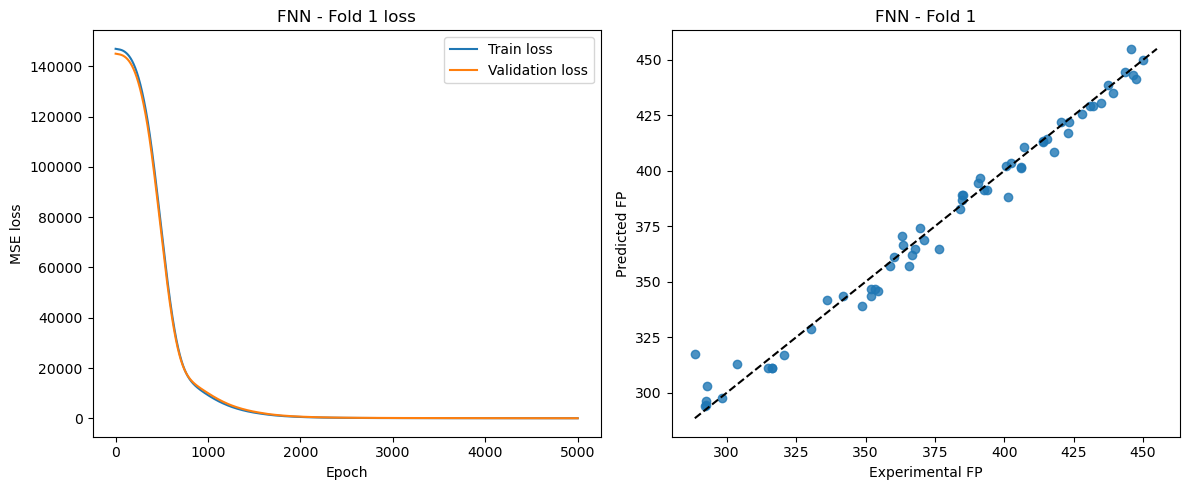

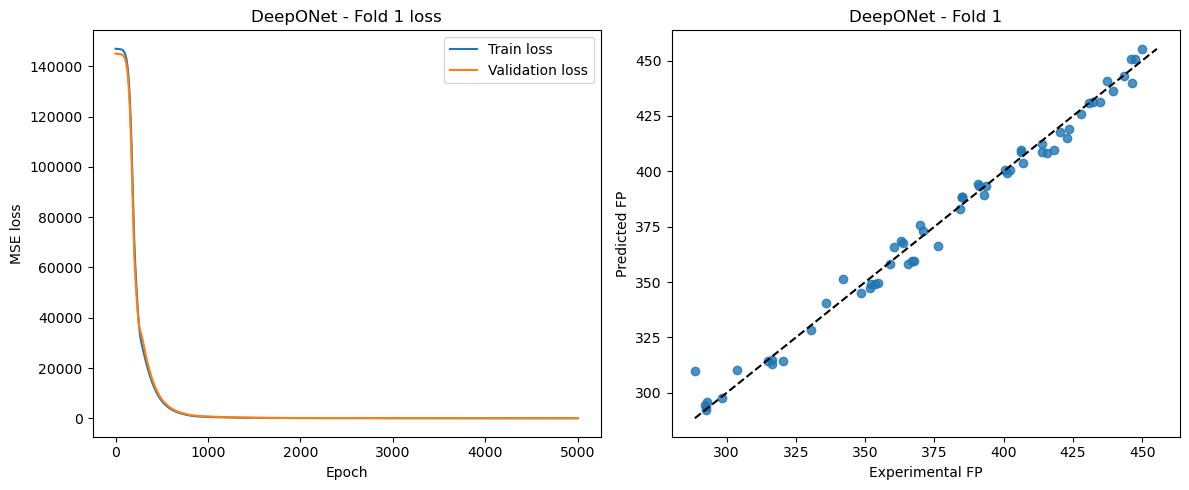

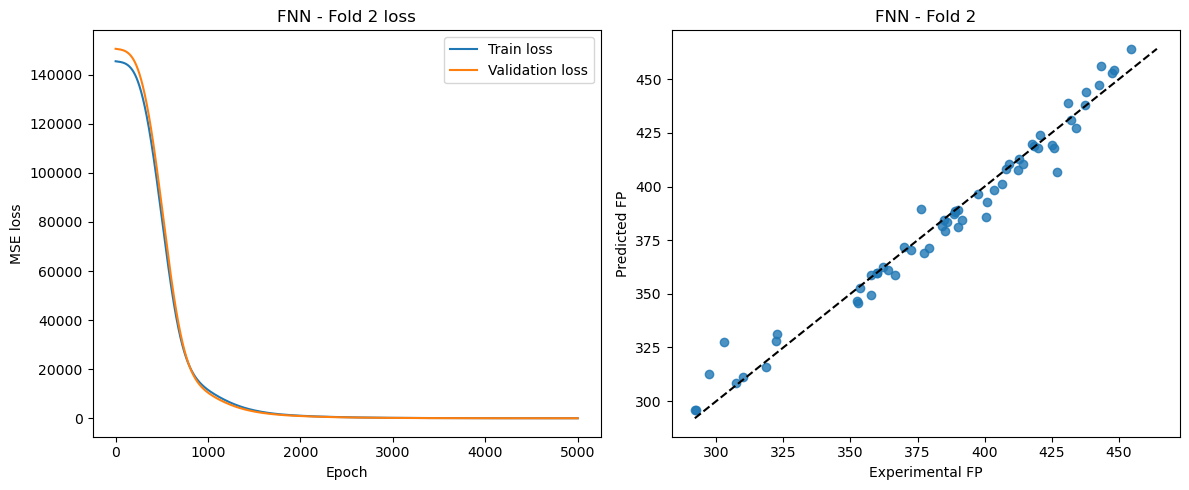

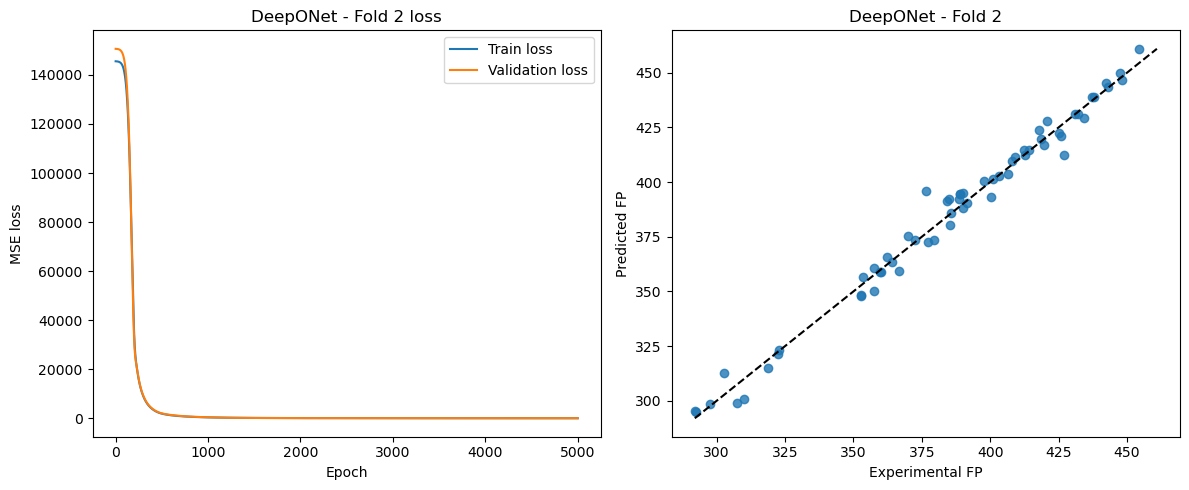

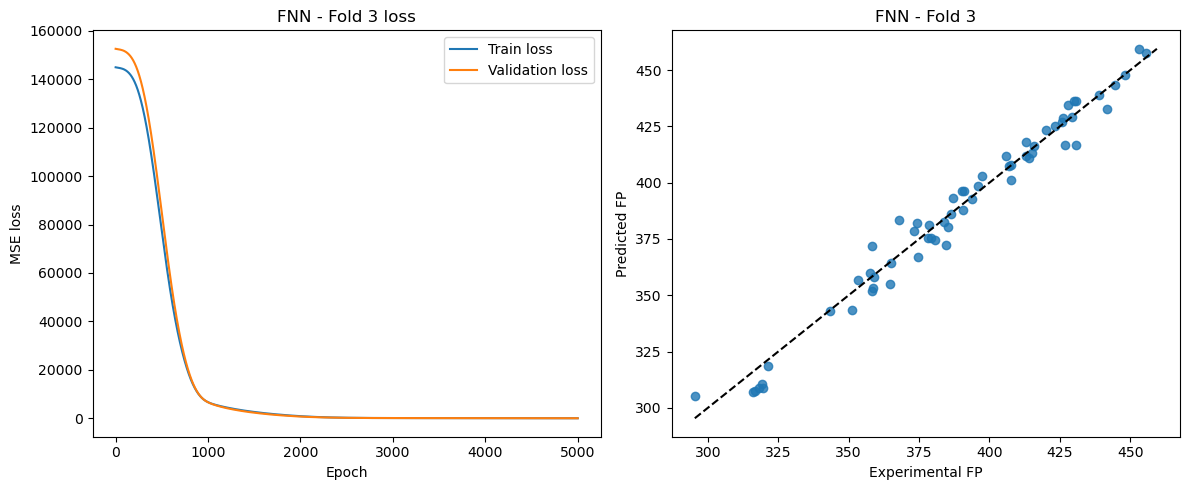

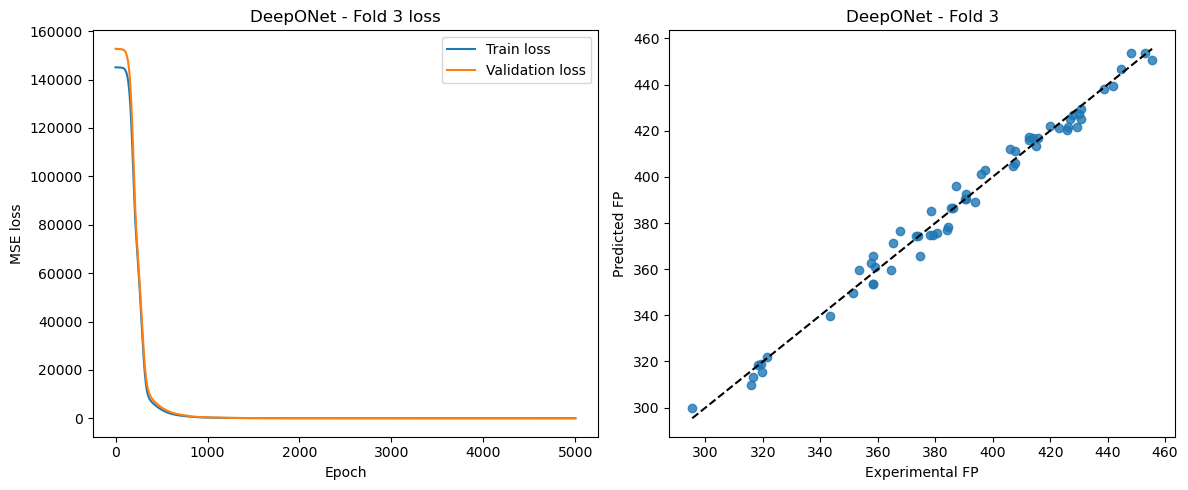

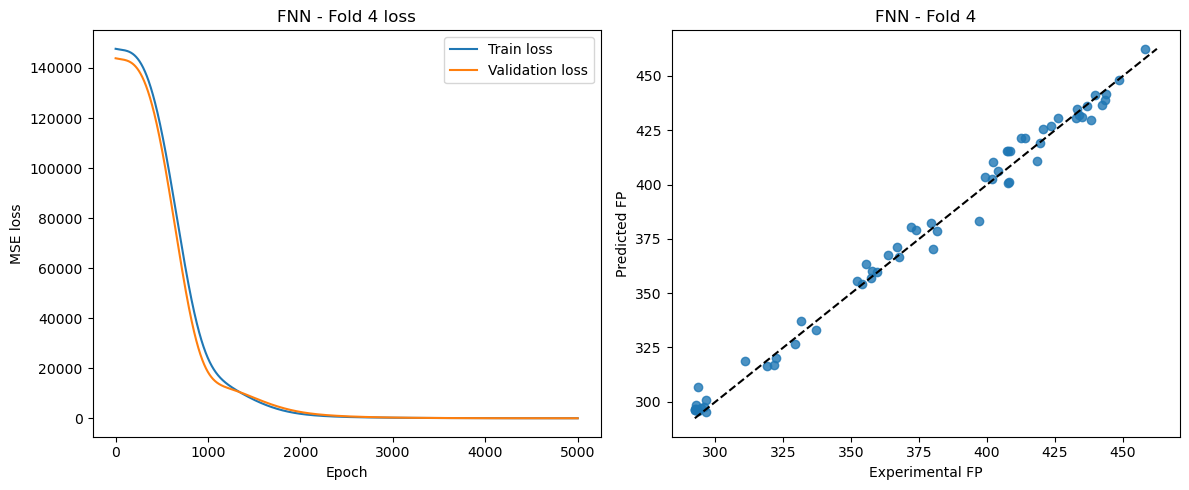

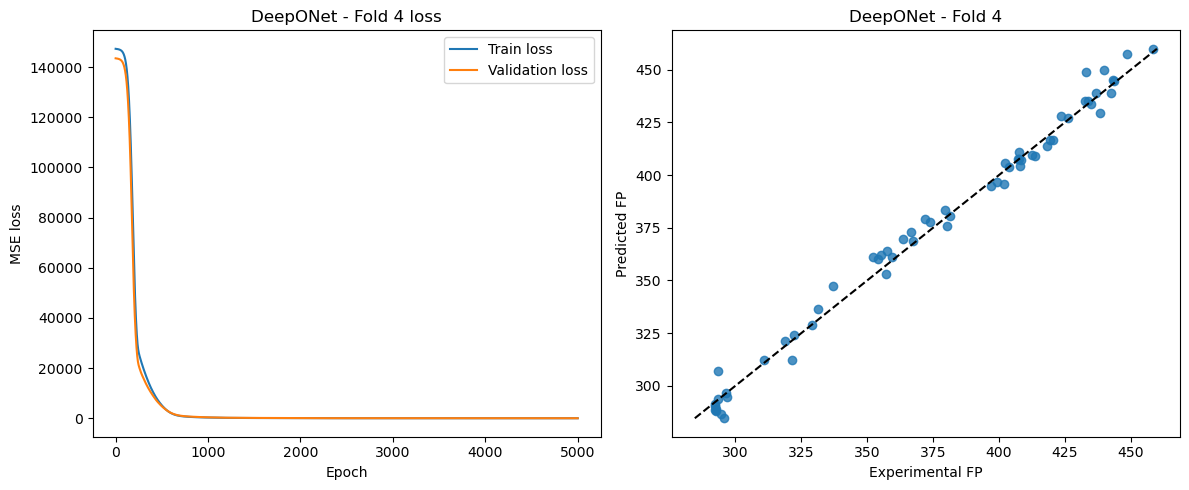

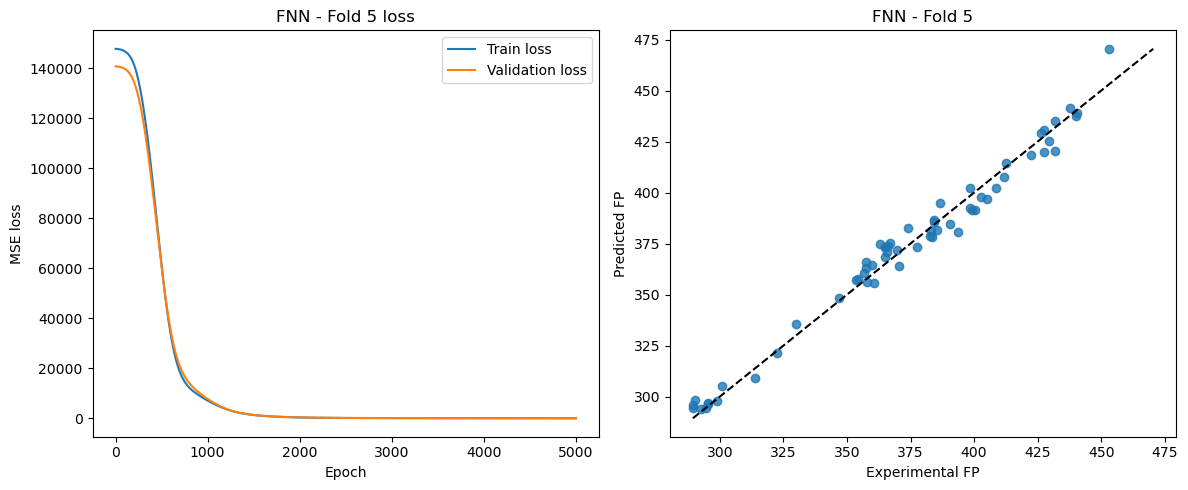

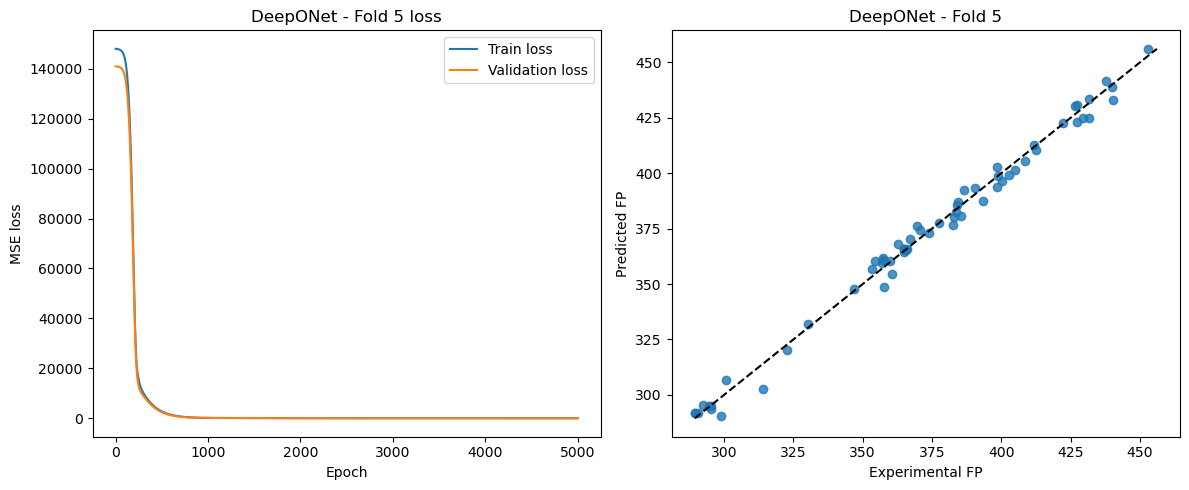

In [6]:
# Define features for each model
fnn_features = filtered_data[["MM", "lnPvap"]].values
branch_features = filtered_data[["x_1", "lnPvap"]].values
trunk_features = filtered_data[["x_1", "MM"]].values
fp_values = filtered_data["FP"].values


# KFold cross-validation
folds = 5
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

fnn_fold_metrics = []
deeponet_fold_metrics = []
deeponet_fold_artifacts = []
fold_predictions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(fnn_features), start=1):
    fnn_scaler = StandardScaler()
    branch_scaler = StandardScaler()
    trunk_scaler = StandardScaler()

    fnn_train = fnn_scaler.fit_transform(fnn_features[train_idx])
    fnn_val = fnn_scaler.transform(fnn_features[val_idx])
    branch_train = branch_scaler.fit_transform(branch_features[train_idx])
    branch_val = branch_scaler.transform(branch_features[val_idx])
    trunk_train = trunk_scaler.fit_transform(trunk_features[train_idx])
    trunk_val = trunk_scaler.transform(trunk_features[val_idx])

    fnn_train_tensor = torch.tensor(fnn_train, dtype=torch.float32).to(DEVICE)
    fnn_val_tensor = torch.tensor(fnn_val, dtype=torch.float32).to(DEVICE)
    branch_train_tensor = torch.tensor(branch_train, dtype=torch.float32).to(DEVICE)
    branch_val_tensor = torch.tensor(branch_val, dtype=torch.float32).to(DEVICE)
    trunk_train_tensor = torch.tensor(trunk_train, dtype=torch.float32).to(DEVICE)
    trunk_val_tensor = torch.tensor(trunk_val, dtype=torch.float32).to(DEVICE)
    y_train_tensor = (
        torch.tensor(fp_values[train_idx], dtype=torch.float32).unsqueeze(1).to(DEVICE)
    )
    y_val_tensor = (
        torch.tensor(fp_values[val_idx], dtype=torch.float32).unsqueeze(1).to(DEVICE)
    )

    fnn_model = FNN(input_dim=fnn_train_tensor.shape[1], output_dim=1).to(DEVICE)
    fnn_train_losses, fnn_val_losses, fnn_val_predictions = train_fnn_fold(
        fnn_model, fnn_train_tensor, y_train_tensor, fnn_val_tensor, y_val_tensor
    )
    fnn_metrics = compute_metrics(fnn_val_predictions, y_val_tensor)
    fnn_metrics["fold"] = fold_idx
    fnn_fold_metrics.append(fnn_metrics)
    plot_fold_results(
        "FNN",
        fold_idx,
        fnn_train_losses,
        fnn_val_losses,
        y_val_tensor,
        fnn_val_predictions,
    )

    deeponet_model = DeepONet(
        branch_dim=branch_train_tensor.shape[1],
        trunk_dim=trunk_train_tensor.shape[1],
        output_dim=1,
    ).to(DEVICE)
    deeponet_train_losses, deeponet_val_losses, deeponet_val_predictions = (
        train_deeponet_fold(
            deeponet_model,
            branch_train_tensor,
            trunk_train_tensor,
            y_train_tensor,
            branch_val_tensor,
            trunk_val_tensor,
            y_val_tensor,
        )
    )
    deeponet_metrics = compute_metrics(deeponet_val_predictions, y_val_tensor)
    deeponet_metrics["fold"] = fold_idx
    deeponet_fold_metrics.append(deeponet_metrics)
    deeponet_fold_artifacts.append(
        {
            "fold": fold_idx,
            "model_state_dict": copy.deepcopy(deeponet_model.state_dict()),
            "branch_scaler": branch_scaler,
            "trunk_scaler": trunk_scaler,
            "rmse (K)": deeponet_metrics["rmse (K)"],
        }
    )
    plot_fold_results(
        "DeepONet",
        fold_idx,
        deeponet_train_losses,
        deeponet_val_losses,
        y_val_tensor,
        deeponet_val_predictions,
    )

    fold_predictions.append(
        {
            "fold": fold_idx,
            "y_true": y_val_tensor.detach().cpu().numpy().ravel(),
            "fnn_predictions": fnn_val_predictions.detach().cpu().numpy().ravel(),
            "deeponet_predictions": deeponet_val_predictions.detach()
            .cpu()
            .numpy()
            .ravel(),
        }
    )


## Models Benchmarking

In [7]:
# Feedforward metrics
fnn_metrics_df = pd.DataFrame(fnn_fold_metrics)
mean_fnn_metrics = fnn_metrics_df.drop(columns=["fold"]).mean()

display(fnn_metrics_df)
print(mean_fnn_metrics)

,mae (K),rmse (K),mape,r2,fold
0,4.576575,6.346580,0.012780,0.981529,1
1,5.150570,7.148598,0.013658,0.971584,2
2,5.051157,6.350927,0.013486,0.972781,3
3,4.433697,5.382037,0.012032,0.989475,4
4,5.110138,6.069175,0.013633,0.981099,5


mae (K)     4.864427
rmse (K)    6.259463
mape        0.013118
r2          0.979294
dtype: float64


In [8]:
# DeepONet metrics
deeponet_metrics_df = pd.DataFrame(deeponet_fold_metrics)
mean_deeponet_metrics = deeponet_metrics_df.drop(columns=["fold"]).mean()

display(deeponet_metrics_df)
print(mean_deeponet_metrics)

,mae (K),rmse (K),mape,r2,fold
0,4.017319,5.179760,0.010960,0.987696,1
1,3.871833,5.246162,0.010317,0.984696,2
2,3.668530,4.397075,0.009579,0.986953,3
3,4.114627,5.359740,0.011328,0.989562,4
4,3.285323,4.082386,0.008923,0.991448,5


mae (K)     3.791527
rmse (K)    4.853025
mape        0.010222
r2          0.988071
dtype: float64


### 1-Butanol + FAEEs Evaluation

Reading the data into a `pandas.DataFrame`:

In [9]:
but_faee_data = pd.read_csv(DATA_PATH / "processed" / "butanol_faee_data.csv")

display(but_faee_data)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method
0,Ethyl Octanoate,NaN,1.00,0.00,172.26460,3.074711,0
1,Butanol,Ethyl Octanoate,0.05,0.95,167.35750,4.171576,0
2,Butanol,Ethyl Octanoate,0.10,0.90,162.45030,4.682051,0
3,Butanol,Ethyl Octanoate,0.15,0.85,157.54320,5.018373,0
4,Butanol,Ethyl Octanoate,0.20,0.80,152.63600,5.269604,0
...,...,...,...,...,...,...,...
100,Butanol,Ethyl Myristate,0.80,0.20,110.58210,6.562587,0
101,Butanol,Ethyl Myristate,0.85,0.15,101.46700,6.623210,0
102,Butanol,Ethyl Myristate,0.90,0.10,92.35185,6.680367,0
103,Butanol,Ethyl Myristate,0.95,0.05,83.23673,6.734432,0


Select the best DeepONet fold and restore its fitted scalers:

In [10]:
best_deeponet_artifact = min(
    deeponet_fold_artifacts, key=lambda artifact: artifact["rmse (K)"]
)

best_deeponet_model = DeepONet(
    branch_dim=branch_features.shape[1],
    trunk_dim=trunk_features.shape[1],
    output_dim=1,
).to(DEVICE)
best_deeponet_model.load_state_dict(best_deeponet_artifact["model_state_dict"])
best_deeponet_model.eval()

branch_scaler = best_deeponet_artifact["branch_scaler"]
trunk_scaler = best_deeponet_artifact["trunk_scaler"]

print(f"Using DeepONet fold {best_deeponet_artifact['fold']} for inference")

Using DeepONet fold 5 for inference


Process the DataFrame using the DeepONet branch (`x_1`, `lnPvap`) and trunk (`x_1`, `MM`) inputs:

In [11]:
but_faee_branch_features = but_faee_data[["x_1", "lnPvap"]].values
but_faee_trunk_features = but_faee_data[["x_1", "MM"]].values

but_faee_branch_scaled = branch_scaler.transform(but_faee_branch_features)
but_faee_trunk_scaled = trunk_scaler.transform(but_faee_trunk_features)

but_faee_branch_tensor = torch.tensor(
    but_faee_branch_scaled, dtype=torch.float32
).to(DEVICE)
but_faee_trunk_tensor = torch.tensor(
    but_faee_trunk_scaled, dtype=torch.float32
).to(DEVICE)

with torch.no_grad():
    but_faee_pred = best_deeponet_model(
        but_faee_branch_tensor, but_faee_trunk_tensor
    )

but_faee_predictions = but_faee_data.copy()
but_faee_predictions["predicted_FP"] = but_faee_pred.detach().cpu().numpy().ravel()

display(but_faee_predictions)

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method,predicted_FP
0,Ethyl Octanoate,NaN,1.00,0.00,172.26460,3.074711,0,358.145081
1,Butanol,Ethyl Octanoate,0.05,0.95,167.35750,4.171576,0,351.384308
2,Butanol,Ethyl Octanoate,0.10,0.90,162.45030,4.682051,0,338.736664
3,Butanol,Ethyl Octanoate,0.15,0.85,157.54320,5.018373,0,331.725006
4,Butanol,Ethyl Octanoate,0.20,0.80,152.63600,5.269604,0,328.445740
...,...,...,...,...,...,...,...,...
100,Butanol,Ethyl Myristate,0.80,0.20,110.58210,6.562587,0,318.279053
101,Butanol,Ethyl Myristate,0.85,0.15,101.46700,6.623210,0,314.810516
102,Butanol,Ethyl Myristate,0.90,0.10,92.35185,6.680367,0,311.238312
103,Butanol,Ethyl Myristate,0.95,0.05,83.23673,6.734432,0,307.559906


Plot predicted FP values as a function of `x_1` for each binary system:

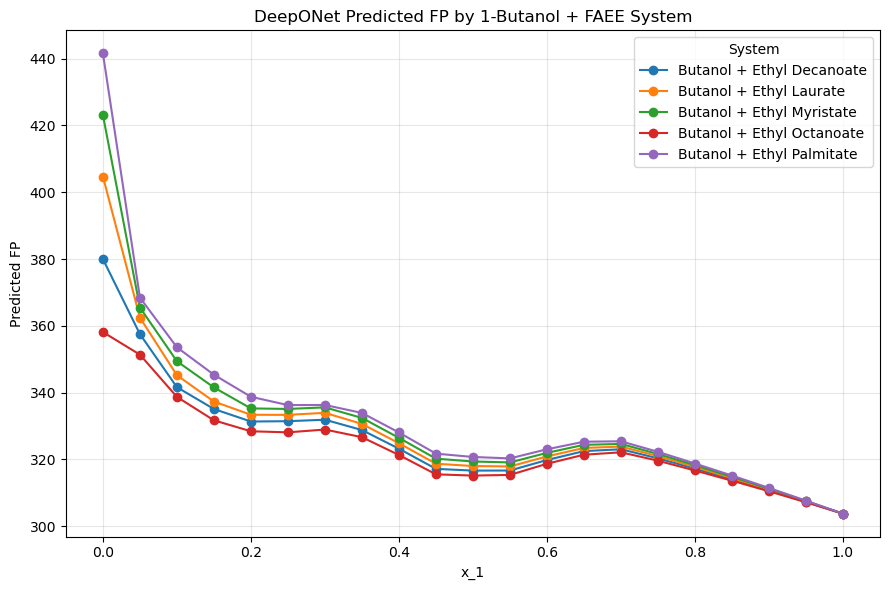

In [12]:
binary_system_predictions = but_faee_predictions.loc[
    but_faee_predictions["substance_2"].notna()
    & (but_faee_predictions["substance_2"] != "")
].copy()
pure_component_predictions = but_faee_predictions.loc[
    but_faee_predictions["substance_2"].isna()
    | (but_faee_predictions["substance_2"] == "")
].copy()
pure_butanol_prediction = pure_component_predictions.loc[
    pure_component_predictions["substance_1"] == "Butanol"
].iloc[0]

plt.figure(figsize=(9, 6))
for ester_name, system_data in binary_system_predictions.groupby("substance_2"):
    pure_ester_prediction = pure_component_predictions.loc[
        pure_component_predictions["substance_1"] == ester_name
    ].iloc[0]
    system_data = system_data.copy()
    system_data["plot_x_1"] = system_data["x_1"]
    system_data = pd.concat(
        [
            pd.DataFrame(
                {
                    "plot_x_1": [0.0],
                    "predicted_FP": [pure_ester_prediction["predicted_FP"]],
                }
            ),
            system_data[["plot_x_1", "predicted_FP"]],
            pd.DataFrame(
                {
                    "plot_x_1": [1.0],
                    "predicted_FP": [pure_butanol_prediction["predicted_FP"]],
                }
            ),
        ],
        ignore_index=True,
    ).sort_values("plot_x_1")
    plt.plot(
        system_data["plot_x_1"],
        system_data["predicted_FP"],
        marker="o",
        label=f"Butanol + {ester_name}",
    )

plt.xlabel("x_1")
plt.ylabel("Predicted FP")
plt.title("DeepONet Predicted FP by 1-Butanol + FAEE System")
plt.legend(title="System")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()